In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import gc
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback)
from transformers import logging
logging.set_verbosity_error()

In [5]:
df = pd.read_csv("balanced_reddit_posts_dataset2.csv")

In [6]:
texts = df["clean_text"].astype(str)
labels = df["category"]

label_mapping = {-1: 0, 0: 1, 1: 2}
y = df["category"].map(label_mapping).astype(int).values

num_labels = 3

In [7]:
le = LabelEncoder()
y = le.fit_transform(labels)
num_labels = len(le.classes_)

In [8]:
train_texts_full, test_texts, train_labels_full, test_labels = train_test_split(
    df["clean_text"].astype(str), y, test_size=0.2, random_state=42, stratify=y
)

# Inner split: 80% train, 20% validation
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts_full, train_labels_full, test_size=0.2, random_state=42, stratify=train_labels_full
)

print(f"Training size: {len(train_texts)}")
print(f"Validation size: {len(val_texts)}")
print(f"Test size: {len(test_texts)}")

Training size: 15840
Validation size: 3960
Test size: 4950


In [9]:
tokenizer = AutoTokenizer.from_pretrained("dost-asti/RoBERTa-tl-sentiment-analysis")

def tokenize(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=512
    )

train_encodings = tokenize(train_texts)
val_encodings = tokenize(val_texts)
test_encodings = tokenize(test_texts)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [10]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

In [11]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from sklearn.metrics import accuracy_score, f1_score

model = AutoModelForSequenceClassification.from_pretrained(
    "dost-asti/RoBERTa-tl-sentiment-analysis",
    num_labels=num_labels
)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [12]:
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

In [13]:
def run_experiment(batch_size, lr, epochs=10):
    print(f"\nRunning: batch={batch_size} | lr={lr}")

    model = AutoModelForSequenceClassification.from_pretrained(
        "dost-asti/RoBERTa-tl-sentiment-analysis",
        num_labels=num_labels
    )

    training_args = TrainingArguments(
        output_dir=f"./grid_bs{batch_size}_lr{lr}",
        eval_strategy="epoch",
        save_strategy="epoch",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        logging_steps=50,
        fp16=True,
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    trainer.train()

    metrics = trainer.evaluate()
    f1 = metrics["eval_f1"]
    loss = metrics["eval_loss"]

    print(f"Validation F1 = {f1:.4f}")

    del trainer
    del model
    torch.cuda.empty_cache()
    gc.collect()

    return f1, loss

In [ ]:
batch_sizes = [16, 32]
learning_rates = [2e-5, 3e-5, 5e-5]

results = []
best_f1 = 0
best_params = None

for bs in batch_sizes:
    for lr in learning_rates:
        f1, loss = run_experiment(bs, lr, epochs=10)

        results.append({
            "batch_size": bs,
            "learning_rate": lr,
            "loss": loss,
            "f1": f1
        })

        if f1 > best_f1:
            best_f1 = f1
            best_params = (bs, lr)

print("\nBEST CONFIG: ")
print(best_params, "F1:", round(best_f1, 4))


Running: batch=16 | lr=2e-05


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'loss': '0.8223', 'grad_norm': '12.03', 'learning_rate': '1.99e-05', 'epoch': '0.05051'}
{'loss': '0.7199', 'grad_norm': '6.562', 'learning_rate': '1.98e-05', 'epoch': '0.101'}
{'loss': '0.6998', 'grad_norm': '13.89', 'learning_rate': '1.97e-05', 'epoch': '0.1515'}
{'loss': '0.6065', 'grad_norm': '11.42', 'learning_rate': '1.96e-05', 'epoch': '0.202'}
{'loss': '0.5959', 'grad_norm': '6.458', 'learning_rate': '1.95e-05', 'epoch': '0.2525'}
{'loss': '0.5089', 'grad_norm': '6.137', 'learning_rate': '1.94e-05', 'epoch': '0.303'}
{'loss': '0.5738', 'grad_norm': '11.76', 'learning_rate': '1.929e-05', 'epoch': '0.3535'}
{'loss': '0.5071', 'grad_norm': '9.769', 'learning_rate': '1.919e-05', 'epoch': '0.404'}
{'loss': '0.4363', 'grad_norm': '19.02', 'learning_rate': '1.909e-05', 'epoch': '0.4545'}
{'loss': '0.4557', 'grad_norm': '15.47', 'learning_rate': '1.899e-05', 'epoch': '0.5051'}
{'loss': '0.4436', 'grad_norm': '17.31', 'learning_rate': '1.889e-05', 'epoch': '0.5556'}
{'loss': '0.3762', 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

{'loss': '0.1086', 'grad_norm': '9.746', 'learning_rate': '3.486e-05', 'epoch': '3.03'}
{'loss': '0.07889', 'grad_norm': '11.32', 'learning_rate': '3.435e-05', 'epoch': '3.131'}
{'loss': '0.1037', 'grad_norm': '0.05975', 'learning_rate': '3.385e-05', 'epoch': '3.232'}
{'loss': '0.09064', 'grad_norm': '11.62', 'learning_rate': '3.334e-05', 'epoch': '3.333'}
{'loss': '0.07609', 'grad_norm': '0.2737', 'learning_rate': '3.284e-05', 'epoch': '3.434'}
{'loss': '0.09463', 'grad_norm': '13.57', 'learning_rate': '3.233e-05', 'epoch': '3.535'}
{'loss': '0.06705', 'grad_norm': '6.092', 'learning_rate': '3.183e-05', 'epoch': '3.636'}
{'loss': '0.09847', 'grad_norm': '7.705', 'learning_rate': '3.132e-05', 'epoch': '3.737'}
{'loss': '0.09487', 'grad_norm': '0.3995', 'learning_rate': '3.082e-05', 'epoch': '3.838'}
{'loss': '0.08159', 'grad_norm': '0.4323', 'learning_rate': '3.031e-05', 'epoch': '3.939'}
{'eval_loss': '0.4643', 'eval_accuracy': '0.9025', 'eval_f1': '0.9031', 'eval_runtime': '28.64', '

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.06486', 'grad_norm': '7.565', 'learning_rate': '2.981e-05', 'epoch': '4.04'}
{'loss': '0.05448', 'grad_norm': '2.461', 'learning_rate': '2.93e-05', 'epoch': '4.141'}
{'loss': '0.07422', 'grad_norm': '24', 'learning_rate': '2.88e-05', 'epoch': '4.242'}
{'loss': '0.03657', 'grad_norm': '0.01951', 'learning_rate': '2.829e-05', 'epoch': '4.343'}
{'loss': '0.06339', 'grad_norm': '0.02968', 'learning_rate': '2.779e-05', 'epoch': '4.444'}
{'loss': '0.07799', 'grad_norm': '15.21', 'learning_rate': '2.728e-05', 'epoch': '4.545'}
{'loss': '0.04909', 'grad_norm': '0.08144', 'learning_rate': '2.678e-05', 'epoch': '4.646'}
{'loss': '0.05901', 'grad_norm': '1.296', 'learning_rate': '2.627e-05', 'epoch': '4.747'}
{'loss': '0.07478', 'grad_norm': '0.1934', 'learning_rate': '2.577e-05', 'epoch': '4.848'}
{'loss': '0.05054', 'grad_norm': '0.5641', 'learning_rate': '2.526e-05', 'epoch': '4.949'}
{'eval_loss': '0.3185', 'eval_accuracy': '0.9268', 'eval_f1': '0.9269', 'eval_runtime': '28.9', 'e

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '2137', 'train_samples_per_second': '74.13', 'train_steps_per_second': '2.317', 'train_loss': '0.1933', 'epoch': '5'}
{'eval_loss': '0.2555', 'eval_accuracy': '0.9247', 'eval_f1': '0.9247', 'eval_runtime': '29.25', 'eval_samples_per_second': '135.4', 'eval_steps_per_second': '4.239', 'epoch': '5'}
Validation F1 = 0.9247

BEST CONFIG: 
(16, 5e-05) F1: 0.9301


In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("f1", ascending=False)

print(results_df)

   batch_size  learning_rate      loss        f1
2          16        0.00005  0.311765  0.930131
5          32        0.00005  0.255471  0.924738
1          16        0.00003  0.265976  0.920528
3          32        0.00002  0.274245  0.912783
0          16        0.00002  0.315263  0.907715
4          32        0.00003  0.280283  0.905717


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
checkpoint_path = "/content/drive/MyDrive/checkpoint"

model = AutoModelForSequenceClassification.from_pretrained(checkpoint_path)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [22]:
training_args = TrainingArguments(
    output_dir="./evaluation",
    per_device_eval_batch_size=16,
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics
)

In [23]:
pred_test = trainer.predict(test_dataset)
preds_test = np.argmax(pred_test.predictions, axis=1)

In [24]:
sentiment_names = ["negative", "neutral", "positive"]

print(classification_report(
    test_labels,
    preds_test,
    target_names=sentiment_names
))

              precision    recall  f1-score   support

    negative       0.89      0.90      0.89      1650
     neutral       0.94      0.97      0.95      1650
    positive       0.91      0.87      0.89      1650

    accuracy                           0.91      4950
   macro avg       0.91      0.91      0.91      4950
weighted avg       0.91      0.91      0.91      4950



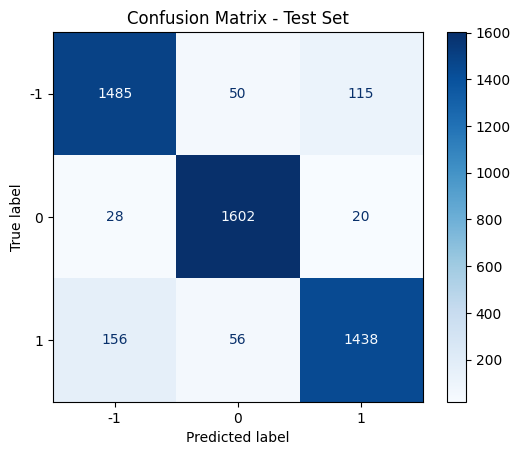

In [25]:
cm = confusion_matrix(test_labels, preds_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.show()

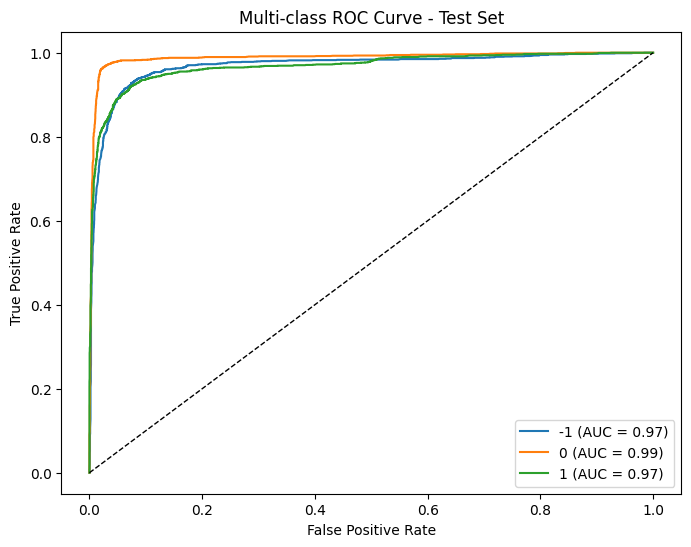

In [26]:
y_test_bin = label_binarize(test_labels, classes=range(num_labels))
y_score = pred_test.predictions

plt.figure(figsize=(8,6))
for i in range(num_labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve - Test Set")
plt.legend(loc="lower right")
plt.show()